In [69]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import odeint
import copy 
import matplotlib.tri as tri

notebookroot = 'spin_01_'  


# Hamiltonian model, lets do something quite general with a pile of free parameters 

\begin{align}
 H(\phi,p,\tau) &= a J_z^2 + \omega_x J_x + \omega_y J_y  + \omega_z J_z \\
 &+ \mu_x J_x  \cos(\tau + \beta_z)  + \mu_y J_y \cos(\tau + \beta_y) 
 + \mu_z J_z\cos(\tau + \beta_z)
 \end{align}
With
\begin{align}
p &= 1- \cos \theta\\
J_x & = \sin \theta \cos \phi  = \sqrt{1 - (p-1)^2} \cos \phi\\
J_y & = \sin \theta \sin \phi  = \sqrt{1 - (p-1)^2} \sin \phi\\
J_z & = \cos \theta = 1 - p
\end{align}
\begin{align}
\frac{\partial J_x}{\partial p} &= \frac{-\cos \phi}{\sqrt{(1 - (p-1)^2)}} (p-1) = \frac{ \cos \theta }{\sin\theta}\cos \phi\\
\frac{\partial J_y}{\partial p} &= \frac{ \cos \theta }{\sin\theta}\sin \phi\\
\frac{\partial J_z}{\partial p} &= -1\\
\frac{\partial J_z^2}{\partial p} &= 2(p-1) = - 2\cos \theta
\end{align}
\begin{align}
\frac{\partial J_x}{\partial \phi} &= - \sqrt{1 - (p-1)^2} \sin \phi \\
\frac{\partial J_y}{\partial \phi} &=  \sqrt{1 - (p-1)^2} \cos \phi \\
\frac{\partial J_z}{\partial \phi} &=  0 
\end{align}

\begin{align}
\frac{\partial H}{\partial p} & = a \frac{\partial J_z^2}{\partial p} \\
& + (\omega_x + \mu_x \cos (\tau + \beta_x) ) \frac{\partial J_x}{\partial p} \\
& + (\omega_y + \mu_y \cos (\tau + \beta_y) ) \frac{\partial J_y}{\partial p} \\
& + (\omega_z + \mu_z \cos (\tau + \beta_z) ) \frac{\partial J_z}{\partial p} 
\end{align}

\begin{align}
\frac{\partial H}{\partial \phi} & = a \frac{\partial J_z^2}{\partial \phi} \\
& + (\omega_x + \mu_x \cos (\tau + \beta_x) ) \frac{\partial J_x}{\partial \phi} \\
& + (\omega_y + \mu_y \cos (\tau + \beta_y) ) \frac{\partial J_y}{\partial \phi} \\
& + (\omega_z + \mu_z \cos (\tau + \beta_z) ) \frac{\partial J_z}{\partial \phi} 
\end{align}

For $H(\phi,p)$, 
Hamilton's equations 
\begin{align}
\dot \phi &= \frac{\partial H}{\partial p} \\
\dot p &=- \frac{\partial H}{\partial \phi}
\end{align}

In [50]:
# dy/dtau = func(y,tau), needed for integrator! odeint 
# note that y[0] = phi and y[1] = p

def cfunc(y,tau,parms):
    a = parms[0]
    omega_x = parms[1]
    omega_y = parms[2]
    omega_z = parms[3]
    mu_x = parms[4]
    mu_y = parms[5]
    mu_z = parms[6]
    beta_x = parms[7]
    beta_y = parms[8]
    beta_z = parms[9]
    
    phi = y[0]
    p = y[1]  # in [0,2]
    ctheta = 1.0-p   # cosine theta ranges from [1 , -1]
    stheta = np.sqrt(1.0 - ctheta*ctheta)  # if p=0, ctheta =1, theta=0,stheta=0, if p=1 ctheta=0, theta=pi/2, stheta=1
    # sin theta ranges from [0,1] and we don't need to worry about the sign of it
    cphi = np.cos(phi)
    sphi = np.sin(phi)
    
    dJxdp = ctheta/stheta * cphi
    dJydp = ctheta/stheta * sphi
    dJzdp = -1.0
    dJz2dp = 2.0*(p-1.0)
    dJxdphi = -stheta*sphi
    dJydphi =  stheta*cphi
    dJzdphi = 0.0
    dJz2dphi = 0.0
    
    ctx = np.cos(tau + beta_x) 
    cty = np.cos(tau + beta_y) 
    ctz = np.cos(tau + beta_z) 
    
    dHdp = a*dJz2dp + (omega_x + mu_x*ctx)*dJxdp + (omega_y + mu_y*cty)*dJydp + (omega_z + mu_z*ctz)*dJzdp
    dHdphi = a*dJz2dphi + (omega_x + mu_x*ctx)*dJxdphi + (omega_y + mu_y*cty)*dJydphi + (omega_z + mu_z*ctz)*dJzdphi

    dydt = [dHdp,-dHdphi]  # [dot phi, dot p] 
    return dydt

# the Hamiltonian itself
def Have(phi,p,tau,parms):
    a = parms[0]
    omega_x = parms[1]
    omega_y = parms[2]
    omega_z = parms[3]
    mu_x = parms[4]
    mu_y = parms[5]
    mu_z = parms[6]
    beta_x = parms[7]
    beta_y = parms[8]
    beta_z = parms[9]
    
    #phi = y[0]
    #p = y[1]
    ctheta = 1.0-p
    stheta = np.sqrt(1.0 - ctheta*ctheta)
    cphi = np.cos(phi)
    sphi = np.sin(phi)

    ctx = np.cos(tau + beta_x) 
    cty = np.cos(tau + beta_y) 
    ctz = np.cos(tau + beta_z) 
      
    Jz = ctheta; Jx = cphi*stheta; Jy = sphi*stheta
    Jz2 = ctheta*ctheta 
    H = a*Jz2 + (omega_x + mu_x*ctx)*Jx + (omega_y + mu_y*cty)*Jy + (omega_z + mu_z*ctz)*Jz
    return H

# make a string that so we can print parameters
def mk_parmstring(parms):
    a = parms[0]
    omega_x = parms[1]
    omega_y = parms[2]
    omega_z = parms[3]
    mu_x = parms[4]
    mu_y = parms[5]
    mu_z = parms[6]
    beta_x = parms[7]
    beta_y = parms[8]
    beta_z = parms[9]
    parmstring = r'$a$' + '={:.1f},'.format(a)
    parmstring += r'$\omega$' + '=({:.1f},{:.1f},{:.1f}),'.format(omega_x,omega_y,omega_z)
    parmstring += r'$\mu$' + '=({:.1f},{:.1f},{:.1f}),'.format(mu_x,mu_y,mu_z)
    parmstring += r'$\beta$' + '=({:.1f},{:.1f},{:.1f})'.format(beta_x,beta_y,beta_z)
    return parmstring

-0.19994730112592035 1.0082844191673401


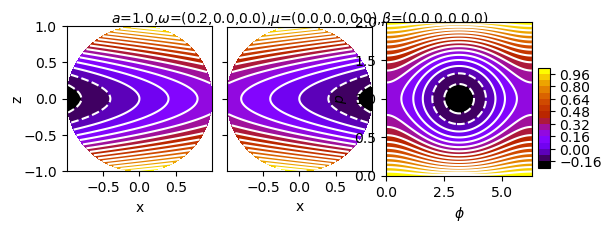

In [57]:
# show level curves of Hamiltonian model 
def mksfig(phi,p,parms,ofile=''):
    tau = 0.0 
    H = Have(phi,p,tau,parms)  # compute Hamiltonian 
    min_H = np.min(H)
    max_H = np.max(H)
    ctheta = (1.0 - p)
    theta = np.arccos(ctheta)
    stheta = np.sqrt(1-ctheta*ctheta)
    cmap = 'gnuplot'
    
    fig,axarr = plt.subplots(1,3,figsize=(6,2))
    plt.subplots_adjust(wspace=0.1,hspace=0)
    x = np.cos(phi)*stheta
    y = np.sin(phi)*stheta
    z = ctheta 
    ii1 = y>=0; ii2 = y<0
    xshort1 = np.ravel(x[ii1]);  yshort1 = np.ravel(y[ii1]); zshort1 = np.ravel(z[ii1]);
    xshort2 = np.ravel(x[ii2]);  yshort2 = np.ravel(y[ii2]); zshort2 = np.ravel(z[ii2]);
    Hshort1 = np.ravel(H[ii1]);Hshort2 = np.ravel(H[ii2]);
    triang1 = tri.Triangulation(xshort1,zshort1)
    triang2 = tri.Triangulation(-xshort2,zshort2)  # notice flipping x for back side!
    clvs=15; ccolor = 'white'
    im = axarr[0].tricontourf(triang1, Hshort1, cmap =cmap,levels=clvs,vmin=min_H, vmax=max_H)
    im = axarr[1].tricontourf(triang2, Hshort2, cmap =cmap,levels=clvs,vmin=min_H, vmax=max_H)
    cc = axarr[0].tricontour(triang1,Hshort1,levels=clvs,colors=ccolor,vmin=min_H, vmax=max_H)
    axarr[1].tricontour(triang2,Hshort2,levels=clvs,colors=ccolor,vmin=min_H, vmax=max_H)
    axarr[0].set_aspect(1)
    axarr[1].set_aspect(1)
    im = axarr[2].contourf(phi,p,H,origin='lower',cmap = cmap,levels=clvs,vmin=min_H, vmax=max_H)
    im.set_clim(min_H,max_H)
    axarr[2].contour(phi,p,H,origin='lower',levels=clvs,colors=ccolor,vmin=min_H, vmax=max_H)
    axarr[2].set_xlabel(r'$\phi$')
    axarr[2].set_ylabel(r'$p$')
    axarr[0].set_ylabel('z',labelpad=-0.5)
    axarr[0].set_xlabel('x')
    axarr[1].set_xlabel('x')
    axarr[1].set(yticklabels=[])
    parmstring = mk_parmstring(parms) 
    axarr[1].text(0,1.1,parmstring,ha='center',va='center')
    print(np.min(H),np.max(H))
    rect = [0.91,0.15,0.02,0.5] # left, bottom, width, height)
    cax = fig.add_axes(rect)
    plt.colorbar(im,cax=cax,orientation='vertical')  # there is still a problem with not covering whole colormap
    #plt.tight_layout() sucks
    if (len(ofile)>2):
        plt.savefig(ofile)
    
    plt.show()

if (1==1): # test level curve figure
    phi_lin = np.linspace(0,2*np.pi,200)
    p_lin = np.linspace(0,2.0,200)
    phi,p = np.meshgrid(phi_lin,p_lin,indexing='xy') 
    a = 1.0
    omega_x = 0.2; omega_y = 0.0; omega_z = 0.0;
    mu_x = 0.0; mu_y = 0.0; mu_z = 0.0
    beta_x = 0.0; beta_y = 0.0; beta_z = 0.0
    parms = np.zeros(10)
    parms[0] = a
    parms[1] = omega_x
    parms[2] = omega_y
    parms[3] = omega_z 
    parms[4] = mu_x 
    parms[5] = mu_y 
    parms[6] = mu_z 
    parms[7] = beta_x 
    parms[8] = beta_y 
    parms[9] = beta_z 

    ofile = notebookroot+'_H.png'
    mksfig(phi,p,parms,ofile=ofile)


In [ ]:
## check that we can integrate
if (1==0):
    y0=np.array([0.1,0.5])
    time = np.array([0.0, 1.1])
    a = 0.1
    omega_x = 1.0; omega_y = 0.0; omega_z = 0.0;
    mu_x = 0.0; mu_y = 0.0; mu_z = 0.0
    beta_x = 0.0; beta_y = 0.0; beta_z = 0.0
    parms = np.zeros(10)
    parms[0] = a
    parms[1] = omega_x;  parms[2] = omega_y; parms[3] = omega_z 
    parms[4] = mu_x;  parms[5] = mu_y; parms[6] = mu_z 
    parms[7] = beta_x; parms[8] = beta_y; parms[9] = beta_z 
    y = odeint(cfunc, y0, time, args=(parms,))
    print(y)

In [45]:
# integrate at a period, the forced top
# arguments:
#   y0: is initial conditions, y=[phi,p]
#   npoints: is number of points we want
#   parms: are parameters of the Hamiltonian model
#
#   integrate every 2 pi period, npoints returned including initial condition 
# returns: phi,p arrays of integrated points 
# this particular routine does all times at once by sending a set of times to the integrator
# globals: cfunc(), odeint()
twopi = 2.0*np.pi
def givepoints_arr(y0,npoints,parms):
    # set up time array, every 2pi/nu so for period of perturbation
    step  = 2.0*np.pi
    stop = step*npoints
    time  = np.arange(0.0,stop,step)  # time array for outputs  goes from 0 to stop-step 
    #                              with increment step, does not reach stop. 
    # do the integration
    y = odeint(cfunc, y0, time, args=(parms,))  # notice the comma so it is a tuple
    phi_arr = np.squeeze(y[:,0])  # is an array of phi at different times
    p_arr = np.squeeze(y[:,1])    # is an array of momenta at different times
    
    phi_arr  = phi_arr%twopi  # so that phi in [0:2pi]
    #ii = phi_arr >np.pi
    #phi_arr[ii]-= twopi # now phi is in [-pi,pi]
    return phi_arr,p_arr 

# integrate points and plot them on axis ax   
def givepoints(y0,npoints,parms,marker,ax):
    phi_arr,p_arr=givepoints_arr(y0,npoints,parms)
    ax.plot(phi_arr,p_arr,marker,markersize=0.5) # plot it

colorlist = ['black','blue','green','magenta','red','orange','gold','blueviolet','springgreen','dodgerblue']

# randomly choose an initial condition, integrate and plot in axis ax 
# arguments:
#    npoints: numbers of points to plot 
#    pmin, pmax constrain the vertical width of randomly chosen initial conditions 
#    parms: parameters for the dynamical model 
#    ax  the axis on which to plot points 
def rand_give_points(npoints,parms,pmin,pmax,ax):
    phi = np.random.uniform(low=0,high=2*np.pi)
    p = np.random.uniform(low=pmin,high=pmax)
    y0 = [phi,p]
    phi_arr,p_arr=givepoints_arr(y0,npoints,parms)
    i = np.random.randint(low=0,high =len(colorlist))
    ax.scatter(phi_arr,p_arr,s=1,edgecolor='none',facecolor=colorlist[i],lw=1)



In [46]:
# a class to store classical model info
#    norb:  numbers of orbits
#    npoints: numbers of points to plot 
#    a,epsilon,mu,mup,b,taushift: parameters for the dynamical model 
#    froot: a root for labeling files 
class Hcla:
    def __init__(self,norb,npoints,parms,froot):
        self.parms = parms
        self.norb = norb
        self.npoints = npoints
        self.froot = froot       

# make a surface of section figure with orbits 
# inputs: a classical model class and a label
def mkfig_cl(cla,alabel):
    norb = cla.norb
    npoints = cla.npoints
    froot = cla.froot
    parms = cla.parms
    
    # set up display
    fig,ax = plt.subplots(1,1,figsize=(3,3),dpi=200) 
    plt.subplots_adjust(bottom=0.18,top=0.90,left=0.18,right=0.98)
    ax.text(6.2,-0.2,r'$\phi$',fontsize=14)
    ax.set_ylabel('p',labelpad=0,fontsize=14)
    #ax.set_aspect('equal')

    dx = 0.01; dy = 0.01
    ax.set_xlim([-dx,2*np.pi + dx])
    ax.set_ylim([-dy,2+dy])

    #ax.text(0,3.4,parm_label,ha='center',va='center')

    for i in range(norb):  # this many orbits , and plots points
        rand_give_points(npoints,parms,0,2,ax)
        
    if (len(alabel)>1):
        plt.text(-0.5,2.2,alabel,fontsize=14)
    if (len(froot)>2):
        ofile = froot + '_class.png'
        print(ofile)
        plt.savefig(ofile,dpi=300)
        
    plt.show()

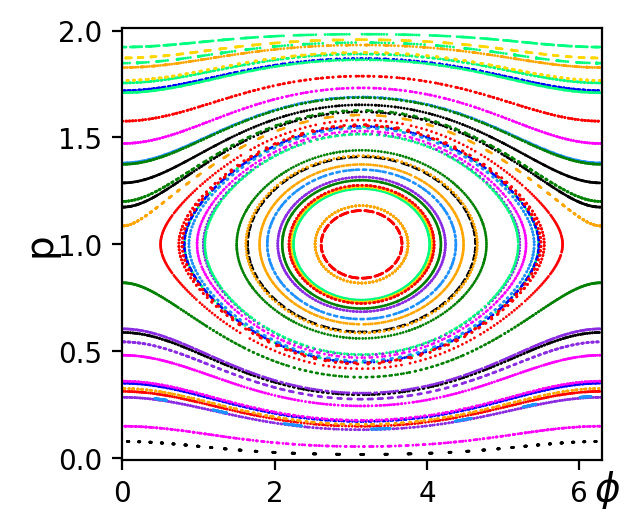

In [72]:
# choose some parameters 
a = 1.0
omega_x = 0.2; omega_y = 0.0; omega_z = 0.0;  # to have a separatrix we need one of these less than a
mu_x = 0.0; mu_y = 0.0; mu_z = 0.0
beta_x = 0.0; beta_y = 0.0; beta_z = 0.0
parms = np.zeros(10)
parms[0] = a
parms[1] = omega_x;  parms[2] = omega_y; parms[3] = omega_z 
parms[4] = mu_x;  parms[5] = mu_y; parms[6] = mu_z 
parms[7] = beta_x; parms[8] = beta_y; parms[9] = beta_z 
norb = 50
npoints = 300
froot = ''
cla_s1 = Hcla(norb,npoints,parms,froot)
alabel = ''
mkfig_cl(cla_s1,alabel)  # non chaotic example 

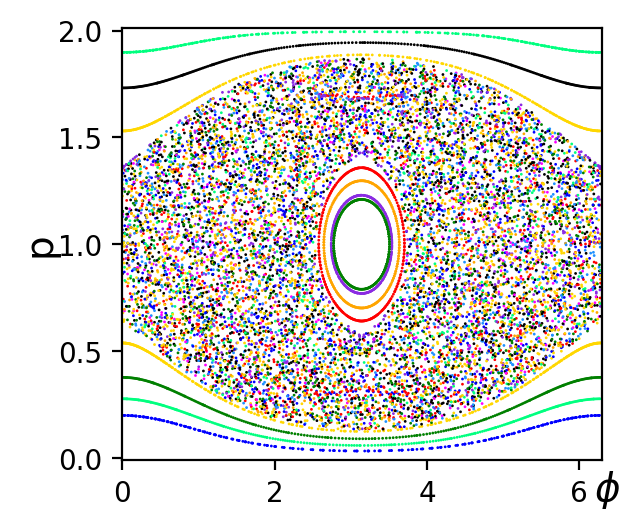

In [71]:
cla_s2 = copy.deepcopy(cla_s1)  #same as s1
mu_x = 0.1
cla_s2.parms[4] = mu_x;
mkfig_cl(cla_s2,alabel)  # 

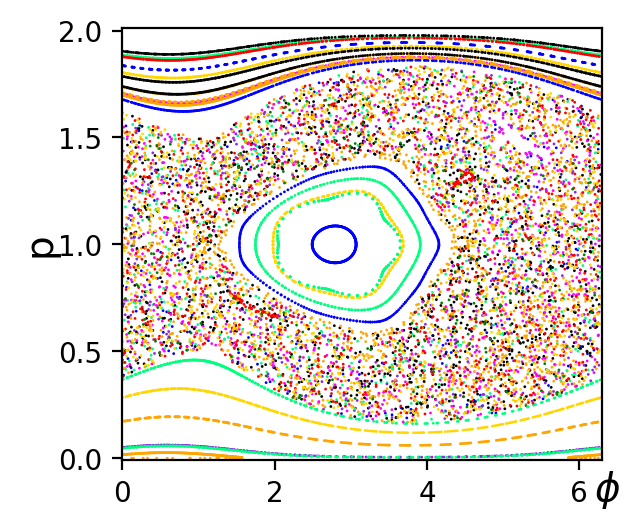

In [75]:
cla_s3 = copy.deepcopy(cla_s1)  #same as s1
mu_y = 0.1
cla_s3.parms[5] = mu_y;
mkfig_cl(cla_s3,alabel)  # 

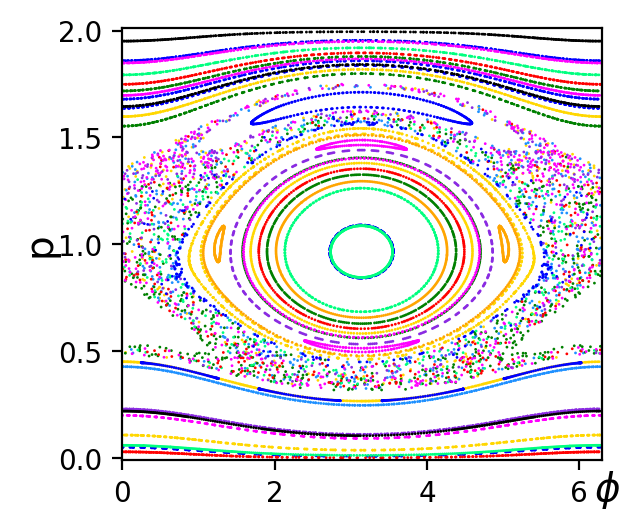

In [76]:
cla_s4 = copy.deepcopy(cla_s1)  #same as s1
mu_z = 0.1
cla_s4.parms[6] = mu_z;
mkfig_cl(cla_s4,alabel)  # 